In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import *

In [4]:
# Load dataset
ds = load_jsonl_file('./../datasets/MATE-dev/mm_0shot_llava_hfllava_1.5_7b_hf.jsonl')
nobjects=3

# Filter dataset for a specific number of objects 
ds_ = [data for data in ds if data['object_count'] == nobjects]

5500it [00:00, 7957.13it/s] 


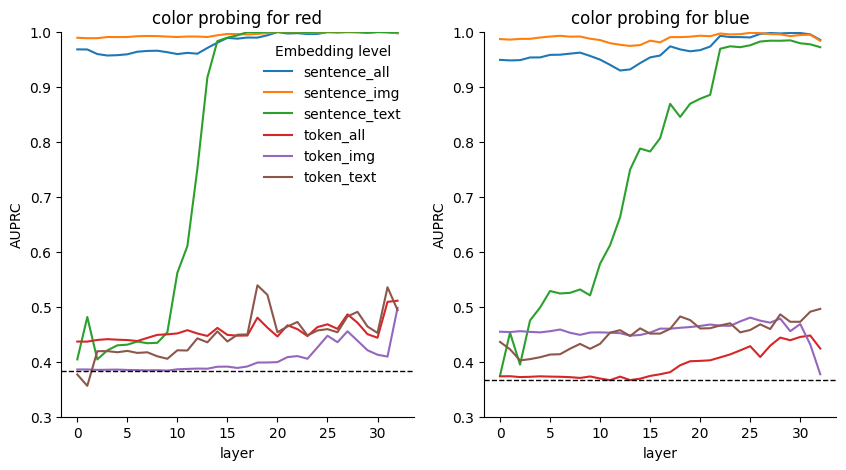

In [7]:
###### plot color probe results
task='color'
target=['red', 'blue','green','yellow', 'gray']
target=['red','blue']
metric = 'auprc'  # 'auroc', 'accuracy', 'auprc'
mode = 'image_and_text'  # 'image', 'text'

fig,axs = plt.subplots(1, len(target), figsize=(5*len(target), 5))

for idx, t in enumerate(target):
    task_df = pd.read_csv(f"./results/llava7B/linear_probing/{mode}/probing_results_{task}_{t}_{nobjects}.csv", index_col=0)

    b = sns.lineplot(data=task_df,
                     x='layer', y='auprc', hue='embedding_level', 
                     ax=axs[idx])
    gold_reference = ['Yes' if t in set([o['color'] for o in data['scene']['objects']]) else 'No' for data in ds_]
    gold_reference_binary = [1 if i=='Yes' else 0 for i in gold_reference]
    baseline = np.sum(gold_reference_binary) / len(gold_reference_binary)

    b.axhline(y=baseline, color='black', linestyle='--', linewidth=1)
    b.set_title(f"{task} probing for {t}")
    b.set_ylabel('AUPRC')

    if idx == 0:
        b.legend(frameon=False,
                 title='Embedding level')
    else:
        b.legend_.remove()

    b.set(ylim=(0.3,1))


sns.despine(top=True, right=True)

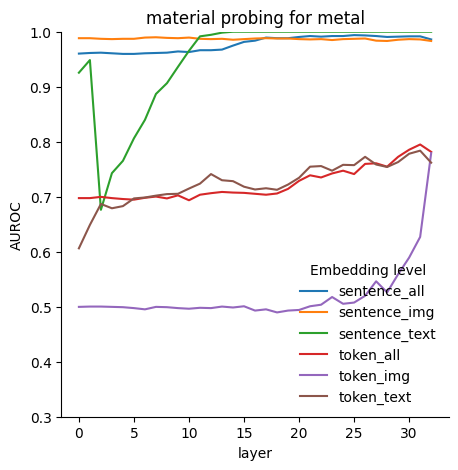

In [6]:
###### plot material probe results
task='material'
target=['metal']
metric = 'auprc'  # 'auroc', 'accuracy', 'auprc'
mode = 'image_and_text'  # 'image', 'text'

fig,axs = plt.subplots(1, len(target), figsize=(5*len(target), 5))

for idx, t in enumerate(target):
    task_df = pd.read_csv(f"./results/llava7B/linear_probing/{mode}/probing_results_{task}_{t}_{nobjects}.csv", index_col=0)

    b = sns.lineplot(data=task_df,
                     x='layer', y='auroc', hue='embedding_level', 
                     ax=axs)
    gold_reference = ['Yes' if t in set([o['color'] for o in data['scene']['objects']]) else 'No' for data in ds_]
    gold_reference_binary = [1 if i=='Yes' else 0 for i in gold_reference]
    baseline = np.sum(gold_reference_binary) / len(gold_reference_binary)

    b.axhline(y=baseline, color='black', linestyle='--', linewidth=1)
    b.set_title(f"{task} probing for {t}")
    b.set_ylabel('AUROC')

    if idx == 0:
        b.legend(frameon=False,
                 title='Embedding level')
    else:
        b.legend_.remove()

    b.set(ylim=(0.3,1))


sns.despine(top=True, right=True)